In [1]:
from gerrychain import Graph
from gerrychain import (GeographicPartition, Partition, Graph, MarkovChain, proposals, updaters, constraints, accept, Election)
from gerrychain.proposals import recom, propose_random_flip
from gerrychain.tree import recursive_tree_part, bipartition_tree, find_balanced_edge_cuts_memoization
from gerrychain.metrics import efficiency_gap, mean_median, polsby_popper, partisan_bias
from gerrychain.updaters import cut_edges

import geopandas as gpd
import matplotlib.pyplot as plt
import networkx as nx

from functools import partial
import numpy as np
import csv
import pandas as pd
import maup

In [2]:
CON_NC = gpd.read_file("./NC/NC_Processed/nc_cong_adopted_2025/NCGA_CCM-2 - Shapefile/CCM-2.shp")

In [3]:
CON_NC22 = gpd.read_file("./NC/NC_Processed/nc_cong_adopted_2022/NC_SMmap2_Statewide.shp")

In [4]:
CON_SC = gpd.read_file("./SC/SC_Processed/sc_cong_adopted_2022/S865_Congress.shp")

In [5]:
CON_GA = gpd.read_file("./GA/GA_Processed/ga_cong_adopted_2023/Congress-2023 shape.shp")

In [6]:
CON_FL = gpd.read_file("./FL/FL_Processed/fl_cong_adopted_2026/EOGPCRP2026/EOGPCRP2026.shp")

In [7]:
CON_FL22 = gpd.read_file("./FL/FL_Processed/fl_cong_adopted_2022/P000C0109.shx")

In [8]:
df_nc = gpd.read_file("./NC/NC_Processed/output/NC_Processed_Precincts.shp")

In [14]:
df_ga = gpd.read_file("./MEW_walkthrough/data/GA/GA_Processed_Precincts.shp")

In [15]:
df_sc = gpd.read_file("./SC/SC_Processed/output/SC_Processed_Precincts.shp")

In [16]:
df_fl = gpd.read_file("./FL/FL_Processed2/FL_Processed_Precincts_take2.shp")

In [17]:
df_al = gpd.read_file("./Processed Precincts/RDH/AL_Processed_Precincts_w_CON21_and23.shp")
df_la = gpd.read_file("./Processed Precincts/RDH/LA_Processed_Precincts_w_CON22_and24.shp")
df_ms = gpd.read_file("./Processed Precincts/RDH/MS_Processed_Precincts.shp")
df_tn = gpd.read_file("./Processed Precincts/RDH/TN_Processed_Precincts_w_CON22.shp")

In [14]:
graph_sc = Graph.from_json("./SC/SC_Processed/output/SC_Processed_Precincts.json")

In [15]:
graph_nc = Graph.from_json("./NC/NC_Processed/output/NC_Processed_Precincts.json")
#graph_nc = Graph.from_geodataframe(df_nc)

In [16]:
graph_ga = Graph.from_json("./MEW_walkthrough/GA/GA_Processed_Precincts.json")

In [17]:
graph_fl = Graph.from_json("./FL/FL_Processed2/FL_Processed_Precincts_take2.json")

In [18]:
con_to_prec = maup.assign(df_nc,CON_NC22.to_crs(df_nc.crs))

df_nc['CON22'] = con_to_prec

graph_nc.add_data(df_nc.set_index('PRECINCTID'),columns=['CON22'])

C:\Users\angel\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\maup\intersections.py:47: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  df = df[df.area > area_cutoff].reset_index(drop=True)
C:\Users\angel\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\maup\intersections.py:48: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  geometries = geometries[geometries.area > area_cutoff]
C:\Users\angel\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\maup\assign.py:38: UserWarning: Geometry is in a geograp

NameError: name 'graph_nc' is not defined

In [22]:
df_la['CON24']

0       3
1       3
2       3
3       3
4       3
       ..
3651    4
3652    4
3653    4
3654    4
3655    4
Name: CON24, Length: 3656, dtype: int64

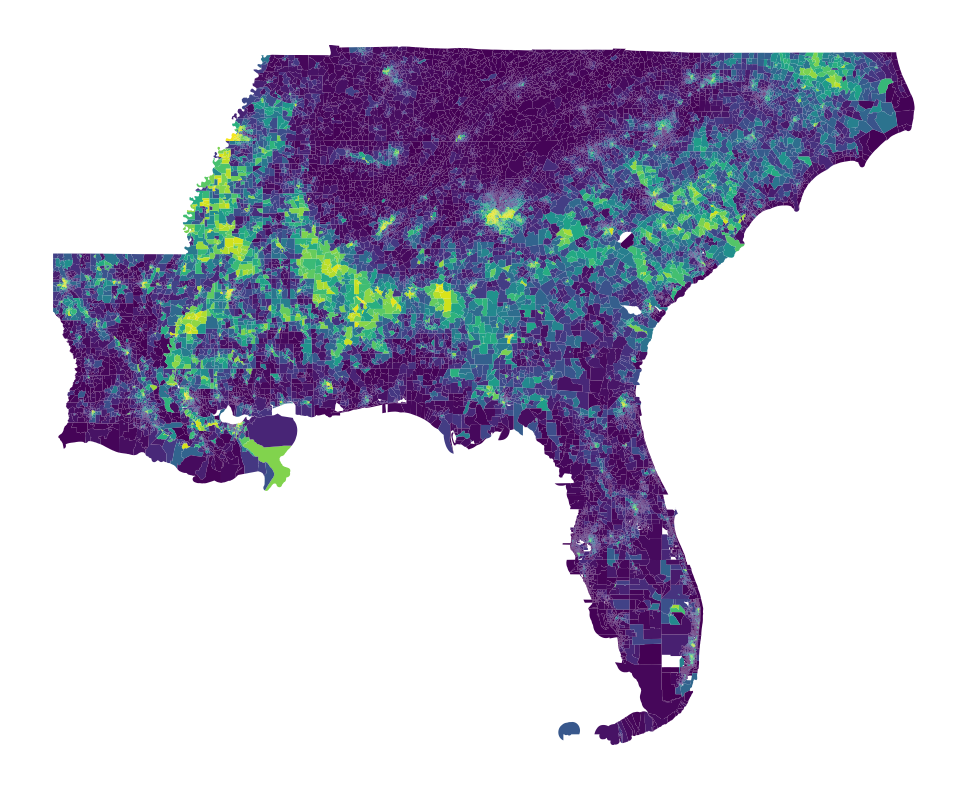

In [ ]:
fig, ax = plt.subplots(figsize=(14,10))
df_nc['b_perc'] = df_nc['NH_Black']/df_nc['population']
df_sc['b_perc'] = df_sc['NH_Black']/df_sc['population']
df_ga['b_perc'] = df_ga['NH_Black']/df_ga['population']
df_fl['b_perc'] = df_fl['NH_Black']/df_fl['population']
df_al['b_perc'] = df_al['NH_Black']/df_al['population']
df_la['b_perc'] = df_la['NH_Black']/df_la['population']
df_ms['b_perc'] = df_ms['NH_Black']/df_ms['population']
df_tn['b_perc'] = df_tn['NH_Black']/df_tn['population']


df_nc.plot(column='b_perc',ax=ax,vmin=0, vmax=1)
#CON_NC.to_crs(df_nc.crs).plot(ax=ax, facecolor='None',edgecolor='white',linewidth=0.5)
df_sc.plot(column='b_perc',ax=ax,vmin=0, vmax=1)
#CON_SC.to_crs(df_nc.crs).plot(ax=ax, facecolor='None',edgecolor='white',linewidth=0.5)
df_ga.plot(column='b_perc',ax=ax,vmin=0, vmax=1)
#CON_GA.to_crs(df_nc.crs).plot(ax=ax, facecolor='None',edgecolor='white',linewidth=0.5)
df_fl.plot(column='b_perc',ax=ax,vmin=0, vmax=1)
#CON_FL.to_crs(df_nc.crs).plot(ax=ax, facecolor='None',edgecolor='white',linewidth=0.5)
df_al.plot(column='b_perc',ax=ax,vmin=0, vmax=1)
df_la.plot(column='b_perc',ax=ax,vmin=0, vmax=1)
df_ms.to_crs(df_nc.crs).plot(column='b_perc',ax=ax,vmin=0, vmax=1)
df_tn.plot(column='b_perc',ax=ax,vmin=0, vmax=1)
ax.set_axis_off()

In [24]:
import matplotlib.colors as mcolors

# Define your explicit color transition
# This goes from Red -> Purple -> Blue
colors = ["red", "purple", "blue"]
custom_rgb_cmap = mcolors.LinearSegmentedColormap.from_list("RedPurpleBlue", colors)

In [19]:
df_tn.keys()

Index(['PRECINCTID', 'population', 'G24PRERTRU', 'G24PREDHAR', 'G24USSDJOH',
       'G24USSRBLA', 'GCON01DJEN', 'GCON01RHAR', 'GCON02DGEO', 'GCON02RBUR',
       'GCON03DALL', 'GCON03RFLE', 'GCON04DBRO', 'GCON04RDES', 'GCON05DABO',
       'GCON05ROGL', 'GCON06DBER', 'GCON06RROS', 'GCON07DBAR', 'GCON07RGRE',
       'GCON08DFRE', 'GCON08RKUS', 'GCON09DCOH', 'GCON09RBER', 'Total',
       'Hispanic', 'NH_White', 'NH_Black', 'NH_Other', 'Total_VAP',
       'Hispanic_V', 'NH_White_V', 'NH_Black_V', 'NH_Other_V', 'COUNTYFP',
       'CON', 'SLDU', 'SLDL', 'C_X', 'C_Y', 'CON22', 'geometry'],
      dtype='object')

In [19]:
dvote_share = sum(df_nc['G24PREDHAR']) + sum(df_sc['G24PREDHAR']) + sum(df_ga['G20PREDBID']) + sum(df_fl['G24PREDHAR']) + sum(df_al['G24PREDHAR']) + sum(df_la['G24PREDHAR']) + sum(df_ms['G24PREDHAR']) + sum(df_tn['G24PREDHAR'])
rvote_share = sum(df_nc['G24PRERTRU']) + sum(df_sc['G24PRERTRU']) + sum(df_ga['G20PRERTRU']) + sum(df_fl['G24PRERTRU']) + sum(df_al['G24PRERTRU']) + sum(df_la['G24PRERTRU']) + sum(df_ms['G24PRERTRU']) + sum(df_tn['G24PRERTRU'])

# of districts total in states
# of dem districts
#dist_curr = len(set(df_nc['CON'])) + len(set(df_sc['CON'])) + len(set(df_fl['CON26'])) + len(set(df_ga['CON']))
#dist_22 = len(set(df_nc['CON22'])) + len(set(df_sc['CON'])) + len(set(df_fl['CON22'])) + len(set(df_ga['CON']))

df_nc["prec_perc"] = df_nc['CON'].map(df_nc.groupby('CON')['G24PREDHAR'].sum()/(df_nc.groupby('CON')['G24PREDHAR'].sum() + df_nc.groupby('CON')['G24PRERTRU'].sum())) 
df_nc["prec_perc22"] = df_nc['CON22'].map(df_nc.groupby('CON22')['G24PREDHAR'].sum()/(df_nc.groupby('CON22')['G24PREDHAR'].sum() + df_nc.groupby('CON22')['G24PRERTRU'].sum())) 
df_sc["prec_perc"] = df_sc['CON'].map(df_sc.groupby('CON')['G24PREDHAR'].sum()/(df_sc.groupby('CON')['G24PREDHAR'].sum() + df_sc.groupby('CON')['G24PRERTRU'].sum())) 
df_ga["prec_perc"] = df_ga['CON'].map(df_ga.groupby('CON')['G20PREDBID'].sum()/(df_ga.groupby('CON')['G20PREDBID'].sum() + df_ga.groupby('CON')['G20PRERTRU'].sum())) 
df_fl["prec_perc"] = df_fl['CON26'].map(df_fl.groupby('CON26')['G24PREDHAR'].sum()/(df_fl.groupby('CON26')['G24PREDHAR'].sum() + df_fl.groupby('CON26')['G24PRERTRU'].sum())) 
df_fl["prec_perc22"] = df_fl['CON22'].map(df_fl.groupby('CON22')['G24PREDHAR'].sum()/(df_fl.groupby('CON22')['G24PREDHAR'].sum() + df_fl.groupby('CON22')['G24PRERTRU'].sum())) 

df_al["prec_perc"] = df_al['CON'].map(df_al.groupby('CON')['G24PREDHAR'].sum()/(df_al.groupby('CON')['G24PREDHAR'].sum() + df_al.groupby('CON')['G24PRERTRU'].sum())) 
df_al["prec_perc22"] = df_al['CON23'].map(df_al.groupby('CON23')['G24PREDHAR'].sum()/(df_al.groupby('CON23')['G24PREDHAR'].sum() + df_al.groupby('CON23')['G24PRERTRU'].sum())) 
df_ms["prec_perc"] = df_ms['CON'].map(df_ms.groupby('CON')['G24PREDHAR'].sum()/(df_ms.groupby('CON')['G24PREDHAR'].sum() + df_ms.groupby('CON')['G24PRERTRU'].sum())) 
df_la["prec_perc"] = df_la['CON'].map(df_la.groupby('CON')['G24PREDHAR'].sum()/(df_la.groupby('CON')['G24PREDHAR'].sum() + df_la.groupby('CON')['G24PRERTRU'].sum())) 
df_la["prec_perc22"] = df_la['CON24'].map(df_la.groupby('CON24')['G24PREDHAR'].sum()/(df_la.groupby('CON24')['G24PREDHAR'].sum() + df_la.groupby('CON24')['G24PRERTRU'].sum()))
df_tn["prec_perc"] = df_tn['CON'].map(df_tn.groupby('CON')['G24PREDHAR'].sum()/(df_tn.groupby('CON')['G24PREDHAR'].sum() + df_tn.groupby('CON')['G24PRERTRU'].sum())) 
df_tn["prec_perc22"] = df_tn['CON22'].map(df_tn.groupby('CON22')['G24PREDHAR'].sum()/(df_tn.groupby('CON22')['G24PREDHAR'].sum() + df_tn.groupby('CON22')['G24PRERTRU'].sum()))

df_nc["nc_dem"] = df_nc['CON'].map(df_nc.groupby('CON')['G24PREDHAR'].sum()/(df_nc.groupby('CON')['G24PREDHAR'].sum() + df_nc.groupby('CON')['G24PRERTRU'].sum()) > 0.5)
df_nc["nc_dem22"] = df_nc['CON22'].map(df_nc.groupby('CON22')['G24PREDHAR'].sum()/(df_nc.groupby('CON22')['G24PREDHAR'].sum() + df_nc.groupby('CON22')['G24PRERTRU'].sum()) > 0.5)
df_sc["sc_dem"] = df_sc['CON'].map(df_sc.groupby('CON')['G24PREDHAR'].sum()/(df_sc.groupby('CON')['G24PREDHAR'].sum() + df_sc.groupby('CON')['G24PRERTRU'].sum()) > 0.5)
df_ga["ga_dem"] = df_ga['CON'].map(df_ga.groupby('CON')['G20PREDBID'].sum()/(df_ga.groupby('CON')['G20PREDBID'].sum() + df_ga.groupby('CON')['G20PRERTRU'].sum()) > 0.5)
df_fl["fl_dem22"] = df_fl['CON22'].map(df_fl.groupby('CON22')['G24PREDHAR'].sum()/(df_fl.groupby('CON22')['G24PREDHAR'].sum() + df_fl.groupby('CON22')['G24PRERTRU'].sum()) > 0.5)
df_fl["fl_dem"] = df_fl['CON26'].map(df_fl.groupby('CON26')['G24PREDHAR'].sum()/(df_fl.groupby('CON26')['G24PREDHAR'].sum() + df_fl.groupby('CON26')['G24PRERTRU'].sum()) > 0.5)
df_al["al_dem"] = df_al['CON'].map(df_al.groupby('CON')['G24PREDHAR'].sum()/(df_al.groupby('CON')['G24PREDHAR'].sum() + df_al.groupby('CON')['G24PRERTRU'].sum()) > 0.5)
df_al["al_dem22"] = df_al['CON23'].map(df_al.groupby('CON23')['G24PREDHAR'].sum()/(df_al.groupby('CON23')['G24PREDHAR'].sum() + df_al.groupby('CON23')['G24PRERTRU'].sum()) > 0.5)
df_ms["ms_dem"] = df_ms['CON'].map(df_ms.groupby('CON')['G24PREDHAR'].sum()/(df_ms.groupby('CON')['G24PREDHAR'].sum() + df_ms.groupby('CON')['G24PRERTRU'].sum()) > 0.5)
df_la["la_dem22"] = df_la['CON24'].map(df_la.groupby('CON24')['G24PREDHAR'].sum()/(df_la.groupby('CON24')['G24PREDHAR'].sum() + df_la.groupby('CON24')['G24PRERTRU'].sum()) > 0.5)
df_la["la_dem"] = df_la['CON'].map(df_la.groupby('CON')['G24PREDHAR'].sum()/(df_la.groupby('CON')['G24PREDHAR'].sum() + df_la.groupby('CON')['G24PRERTRU'].sum()) > 0.5)
df_tn["tn_dem22"] = df_tn['CON22'].map(df_tn.groupby('CON22')['G24PREDHAR'].sum()/(df_tn.groupby('CON22')['G24PREDHAR'].sum() + df_tn.groupby('CON22')['G24PRERTRU'].sum()) > 0.5)
df_tn["tn_dem"] = df_tn['CON'].map(df_tn.groupby('CON')['G24PREDHAR'].sum()/(df_tn.groupby('CON')['G24PREDHAR'].sum() + df_tn.groupby('CON')['G24PRERTRU'].sum()) > 0.5)


In [38]:
df_la["prec_perc22"] 

0       0.271820
1       0.271820
2       0.271820
3       0.271820
4       0.271820
          ...   
3651    0.235158
3652    0.235158
3653    0.235158
3654    0.235158
3655    0.235158
Name: prec_perc22, Length: 3656, dtype: float64

In [28]:
df_la.keys()

Index(['PRECINCTID', 'population', 'G24PRERTRU', 'G24PREDHAR', 'GCON01RSCA',
       'GCON01DMAN', 'GCON02DCAR', 'GCON02RGRA', 'GCON03RHIG', 'GCON03DGON',
       'GCON04RJOH', 'GCON05RLET', 'GCON05DVAL', 'GCON06DFIE', 'GCON06RGUI',
       'Total', 'Hispanic', 'NH_White', 'NH_Black', 'NH_Other', 'Total_VAP',
       'Hispanic_V', 'NH_White_V', 'NH_Black_V', 'NH_Other_V', 'COUNTYFP',
       'CON', 'SLDU', 'SLDL', 'C_X', 'C_Y', 'CON24', 'CON22', 'geometry',
       'prec_perc', 'prec_perc22', 'la_dem22', 'la_dem'],
      dtype='object')

In [20]:
nc_dem = sum(df_nc.groupby('CON')['G24PREDHAR'].sum()/(df_nc.groupby('CON')['G24PREDHAR'].sum() + df_nc.groupby('CON')['G24PRERTRU'].sum()) > 0.5)
nc_dem22= sum(df_nc.groupby('CON22')['G24PREDHAR'].sum()/(df_nc.groupby('CON22')['G24PREDHAR'].sum() + df_nc.groupby('CON22')['G24PRERTRU'].sum()) > 0.5)
sc_dem = sum(df_sc.groupby('CON')['G24PREDHAR'].sum()/(df_sc.groupby('CON')['G24PREDHAR'].sum() + df_sc.groupby('CON')['G24PRERTRU'].sum()) > 0.5)
ga_dem = sum(df_ga.groupby('CON')['G20PREDBID'].sum()/(df_ga.groupby('CON')['G20PREDBID'].sum() + df_ga.groupby('CON')['G20PRERTRU'].sum()) > 0.5)
fl_dem22 = sum(df_fl.groupby('CON22')['G24PREDHAR'].sum()/(df_fl.groupby('CON22')['G24PREDHAR'].sum() + df_fl.groupby('CON22')['G24PRERTRU'].sum()) > 0.5)
fl_dem = sum(df_fl.groupby('CON26')['G24PREDHAR'].sum()/(df_fl.groupby('CON26')['G24PREDHAR'].sum() + df_fl.groupby('CON26')['G24PRERTRU'].sum()) > 0.5)
al_dem = sum(df_al.groupby('CON')['G24PREDHAR'].sum()/(df_al.groupby('CON')['G24PREDHAR'].sum() + df_al.groupby('CON')['G24PRERTRU'].sum()) > 0.5)
al_dem22 = sum(df_al.groupby('CON23')['G24PREDHAR'].sum()/(df_al.groupby('CON23')['G24PREDHAR'].sum() + df_al.groupby('CON23')['G24PRERTRU'].sum()) > 0.5)
ms_dem = sum(df_ms.groupby('CON')['G24PREDHAR'].sum()/(df_ms.groupby('CON')['G24PREDHAR'].sum() + df_ms.groupby('CON')['G24PRERTRU'].sum()) > 0.5)
la_dem22 = sum(df_la.groupby('CON24')['G24PREDHAR'].sum()/(df_la.groupby('CON24')['G24PREDHAR'].sum() + df_la.groupby('CON24')['G24PRERTRU'].sum()) > 0.5)
la_dem = sum(df_la.groupby('CON')['G24PREDHAR'].sum()/(df_la.groupby('CON')['G24PREDHAR'].sum() + df_la.groupby('CON')['G24PRERTRU'].sum()) > 0.5)
tn_dem22 = sum(df_tn.groupby('CON22')['G24PREDHAR'].sum()/(df_tn.groupby('CON22')['G24PREDHAR'].sum() + df_tn.groupby('CON22')['G24PRERTRU'].sum()) > 0.5)
tn_dem = sum(df_tn.groupby('CON')['G24PREDHAR'].sum()/(df_tn.groupby('CON')['G24PREDHAR'].sum() + df_tn.groupby('CON')['G24PRERTRU'].sum()) > 0.5)

In [32]:
total22 = nc_dem22 + sc_dem + ga_dem + fl_dem22 + al_dem22 + ms_dem + la_dem22 + tn_dem22
total = nc_dem + sc_dem + ga_dem + fl_dem + al_dem + ms_dem + la_dem + tn_dem

print(total22)
print(total)

print(dvote_share/(dvote_share + rvote_share))

27
16
0.43225155571553703


In [46]:
print(al_dem)
print(al_dem22)

1
2


In [21]:
fl_bpop = sum(df_fl.groupby('CON26')['NH_Black'].sum()/(df_fl.groupby('CON26')['population'].sum()) > 0.5)
fl_bpop22 = sum(df_fl.groupby('CON22')['NH_Black'].sum()/(df_fl.groupby('CON22')['population'].sum()) > 0.5)

In [22]:
fl_hpop = sum(df_fl.groupby('CON26')['Hispanic'].sum()/(df_fl.groupby('CON26')['population'].sum()) > 0.5)
fl_hpop22 = sum(df_fl.groupby('CON22')['Hispanic'].sum()/(df_fl.groupby('CON22')['population'].sum()) > 0.5)

In [38]:
print(fl_hpop22)
print(fl_hpop)

4
3


In [41]:
tn_bpop = sum(df_tn.groupby('CON')['NH_Black'].sum()/(df_tn.groupby('CON')['population'].sum()) > 0.5)
tn_bpop22 = sum(df_tn.groupby('CON22')['NH_Black'].sum()/(df_tn.groupby('CON22')['population'].sum()) > 0.5)

print(tn_bpop)
print(tn_bpop22)

0
1


In [45]:
nc_bpop = sum(df_nc.groupby('CON')['NH_Black'].sum()/(df_nc.groupby('CON')['population'].sum()) > 0.5)
nc_bpop22 = sum(df_nc.groupby('CON22')['NH_Black'].sum()/(df_nc.groupby('CON22')['population'].sum()) > 0.5)

print(nc_bpop)
print(nc_bpop22)

0
0


In [151]:
print(dist_curr)
print(dist_22)
print(nc_dem + sc_dem + ga_dem + fl_dem)
print(nc_dem22 + sc_dem + ga_dem + fl_dem22)

print(dvote_share/(dvote_share + rvote_share))

63
63
13
21
0.4569630995677287


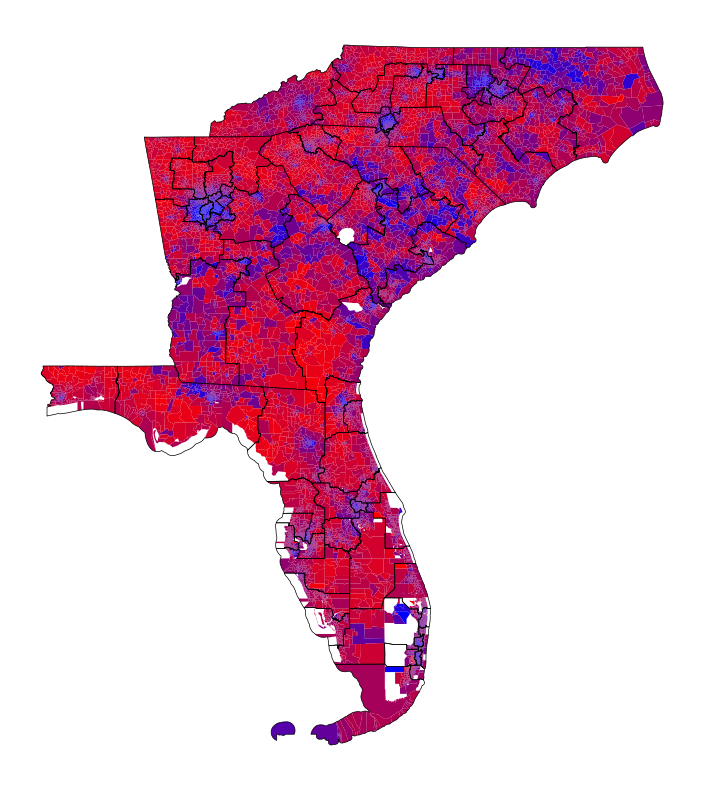

In [25]:
fig, ax = plt.subplots(figsize=(14,10))
df_nc["perc"] = df_nc['G24PREDHAR']/ (df_nc['G24PREDHAR'] + df_nc['G24PRERTRU'])
df_sc["perc"] = df_sc['G24PREDHAR']/ (df_sc['G24PREDHAR'] + df_sc['G24PRERTRU'])
df_ga["perc"] = df_ga['G20PREDBID']/ (df_ga['G20PREDBID'] + df_ga['G20PRERTRU'])
df_fl["perc"] = df_fl['G24PREDHAR']/ (df_fl['G24PREDHAR'] + df_fl['G24PRERTRU'])

df_nc.plot(column='perc',ax=ax,vmin=0, vmax=1, cmap=custom_rgb_cmap)
CON_NC.to_crs(df_nc.crs).plot(ax=ax, facecolor='None',edgecolor='k',linewidth=0.5)
df_sc.plot(column='perc',ax=ax,vmin=0, vmax=1, cmap=custom_rgb_cmap)
CON_SC.to_crs(df_nc.crs).plot(ax=ax, facecolor='None',edgecolor='k',linewidth=0.5)
df_ga.plot(column='perc',ax=ax,vmin=0, vmax=1, cmap=custom_rgb_cmap)
CON_GA.to_crs(df_nc.crs).plot(ax=ax, facecolor='None',edgecolor='k',linewidth=0.5)
df_fl.plot(column='perc',ax=ax,vmin=0, vmax=1, cmap=custom_rgb_cmap)
CON_FL.to_crs(df_nc.crs).plot(ax=ax, facecolor='None',edgecolor='k',linewidth=0.5)
ax.set_axis_off()

In [26]:
prec_al = df_al.dissolve(by='CON', aggfunc='sum')
prec_al22 = df_al.dissolve(by='CON23', aggfunc='sum')
prec_la = df_la.dissolve(by='CON', aggfunc='sum')
prec_la22 = df_la.dissolve(by='CON24', aggfunc='sum')
prec_ms = df_ms.dissolve(by='CON', aggfunc='sum')
prec_tn = df_tn.dissolve(by='CON', aggfunc='sum')
prec_tn22 = df_tn.dissolve(by='CON22', aggfunc='sum')

In [26]:
sorted(df_la["prec_perc22"], reverse=True)

[0.7242816483800812,
 0.7242816483800812,
 0.7242816483800812,
 0.7242816483800812,
 0.7242816483800812,
 0.7242816483800812,
 0.7242816483800812,
 0.7242816483800812,
 0.7242816483800812,
 0.7242816483800812,
 0.7242816483800812,
 0.7242816483800812,
 0.7242816483800812,
 0.7242816483800812,
 0.7242816483800812,
 0.7242816483800812,
 0.7242816483800812,
 0.7242816483800812,
 0.7242816483800812,
 0.7242816483800812,
 0.7242816483800812,
 0.7242816483800812,
 0.7242816483800812,
 0.7242816483800812,
 0.7242816483800812,
 0.7242816483800812,
 0.7242816483800812,
 0.7242816483800812,
 0.7242816483800812,
 0.7242816483800812,
 0.7242816483800812,
 0.7242816483800812,
 0.7242816483800812,
 0.7242816483800812,
 0.7242816483800812,
 0.7242816483800812,
 0.7242816483800812,
 0.7242816483800812,
 0.7242816483800812,
 0.7242816483800812,
 0.7242816483800812,
 0.7242816483800812,
 0.7242816483800812,
 0.7242816483800812,
 0.7242816483800812,
 0.7242816483800812,
 0.7242816483800812,
 0.7242816483

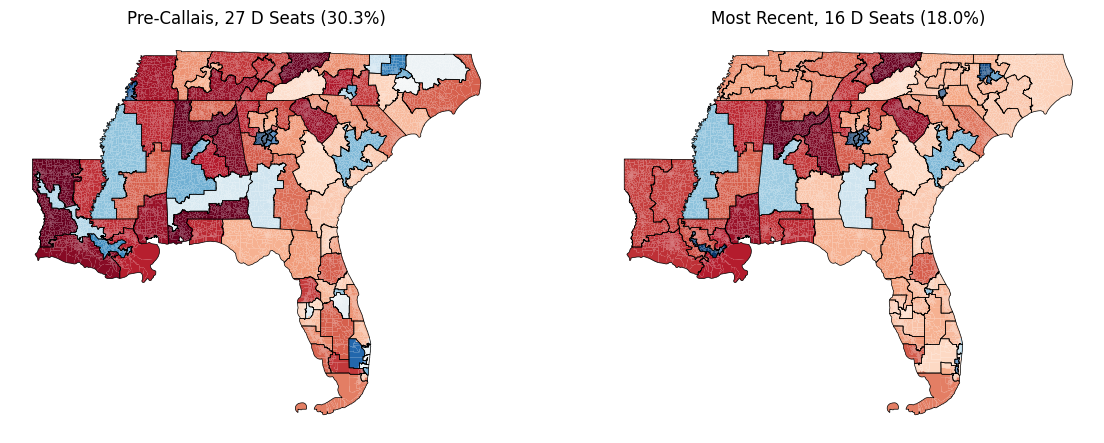

In [37]:
fig, ax = plt.subplots(1, 2, figsize=(14,10))
fig.patch.set_facecolor('none')
ax[0].set_facecolor('none')
ax[1].set_facecolor('none')

df_nc.plot(column='prec_perc22',ax=ax[0],vmin=0.25, vmax=.75,cmap='RdBu')
CON_NC22.to_crs(df_nc.crs).plot(ax=ax[0], facecolor='None',edgecolor='k',linewidth=0.5)
df_sc.plot(column='prec_perc',ax=ax[0],vmin=0.25, vmax=.75,cmap='RdBu')
CON_SC.to_crs(df_nc.crs).plot(ax=ax[0], facecolor='None',edgecolor='k',linewidth=0.5)
df_ga.plot(column='prec_perc',ax=ax[0],vmin=0.25, vmax=.75,cmap='RdBu')
CON_GA.to_crs(df_nc.crs).plot(ax=ax[0], facecolor='None',edgecolor='k',linewidth=0.5)
df_fl.plot(column='prec_perc22',ax=ax[0],vmin=0.25, vmax=.75,cmap='RdBu')
CON_FL22.to_crs(df_nc.crs).plot(ax=ax[0], facecolor='None',edgecolor='k',linewidth=0.5)
df_al.plot(column='prec_perc22',ax=ax[0],vmin=0.25, vmax=.75,cmap='RdBu')
prec_al22.to_crs(df_nc.crs).plot(ax=ax[0], facecolor='None',edgecolor='k',linewidth=0.5)
df_la.plot(column='prec_perc22',ax=ax[0],vmin=0.25, vmax=.75,cmap='RdBu')
prec_la22.to_crs(df_nc.crs).plot(ax=ax[0], facecolor='None',edgecolor='k',linewidth=0.5)
df_ms.to_crs(df_nc.crs).plot(column='prec_perc',ax=ax[0],vmin=0.25, vmax=.75,cmap='RdBu')
prec_ms.to_crs(df_nc.crs).plot(ax=ax[0], facecolor='None',edgecolor='k',linewidth=0.5)
df_tn.plot(column='prec_perc22',ax=ax[0],vmin=0.25, vmax=.75,cmap='RdBu')
prec_tn22.to_crs(df_nc.crs).plot(ax=ax[0], facecolor='None',edgecolor='k',linewidth=0.5)
ax[0].set_title(f"Pre-Callais, 27 D Seats (30.3%)")
ax[0].set_axis_off()

df_nc.plot(column='prec_perc',ax=ax[1],vmin=0.25, vmax=.75,cmap='RdBu')
CON_NC.to_crs(df_nc.crs).plot(ax=ax[1], facecolor='None',edgecolor='k',linewidth=0.5)
df_sc.plot(column='prec_perc',ax=ax[1],vmin=0.25, vmax=.75,cmap='RdBu')
CON_SC.to_crs(df_nc.crs).plot(ax=ax[1], facecolor='None',edgecolor='k',linewidth=0.5)
df_ga.plot(column='prec_perc',ax=ax[1],vmin=0.25, vmax=.75,cmap='RdBu')
CON_GA.to_crs(df_nc.crs).plot(ax=ax[1], facecolor='None',edgecolor='k',linewidth=0.5)
df_fl.plot(column='prec_perc',ax=ax[1],vmin=0.25, vmax=.75,cmap='RdBu')
CON_FL.to_crs(df_nc.crs).plot(ax=ax[1], facecolor='None',edgecolor='k',linewidth=0.5)
df_al.plot(column='prec_perc',ax=ax[1],vmin=0.25, vmax=.75,cmap='RdBu')
prec_al.to_crs(df_nc.crs).plot(ax=ax[1], facecolor='None',edgecolor='k',linewidth=0.5)
df_la.plot(column='prec_perc',ax=ax[1],vmin=0.25, vmax=.75,cmap='RdBu')
prec_la.to_crs(df_nc.crs).plot(ax=ax[1], facecolor='None',edgecolor='k',linewidth=0.5)
df_ms.to_crs(df_nc.crs).plot(column='prec_perc',ax=ax[1],vmin=0.25, vmax=.75,cmap='RdBu')
prec_ms.to_crs(df_nc.crs).plot(ax=ax[1], facecolor='None',edgecolor='k',linewidth=0.5)
df_tn.plot(column='prec_perc',ax=ax[1],vmin=0.25, vmax=.75,cmap='RdBu')
prec_tn.to_crs(df_nc.crs).plot(ax=ax[1], facecolor='None',edgecolor='k',linewidth=0.5)
ax[1].set_title(f"Most Recent, 16 D Seats (18.0%)")
ax[1].set_axis_off()

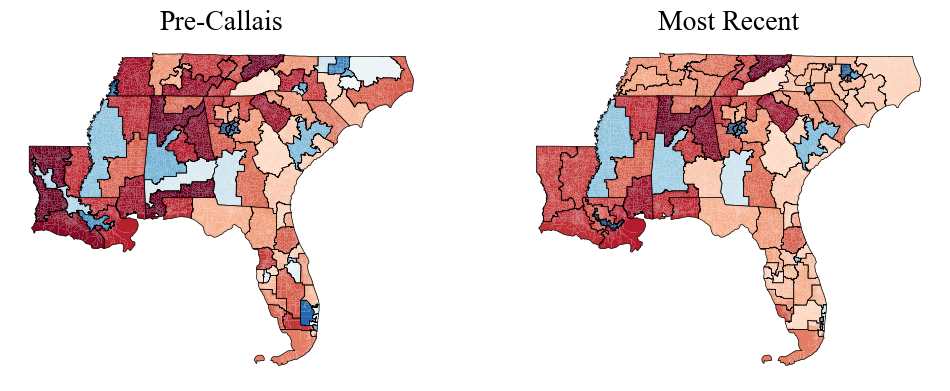

In [30]:
fig, ax = plt.subplots(1, 2, figsize=(12,8.5))
fig.patch.set_facecolor('none')
ax[0].set_facecolor('none')
ax[1].set_facecolor('none')

df_nc.plot(column='prec_perc22',ax=ax[0],vmin=0.25, vmax=.75,cmap='RdBu')
CON_NC22.to_crs(df_nc.crs).plot(ax=ax[0], facecolor='None',edgecolor='k',linewidth=0.5)
df_sc.plot(column='prec_perc',ax=ax[0],vmin=0.25, vmax=.75,cmap='RdBu')
CON_SC.to_crs(df_nc.crs).plot(ax=ax[0], facecolor='None',edgecolor='k',linewidth=0.5)
df_ga.plot(column='prec_perc',ax=ax[0],vmin=0.25, vmax=.75,cmap='RdBu')
CON_GA.to_crs(df_nc.crs).plot(ax=ax[0], facecolor='None',edgecolor='k',linewidth=0.5)
df_fl.plot(column='prec_perc22',ax=ax[0],vmin=0.25, vmax=.75,cmap='RdBu')
CON_FL22.to_crs(df_nc.crs).plot(ax=ax[0], facecolor='None',edgecolor='k',linewidth=0.5)
df_al.plot(column='prec_perc22',ax=ax[0],vmin=0.25, vmax=.75,cmap='RdBu')
prec_al22.to_crs(df_nc.crs).plot(ax=ax[0], facecolor='None',edgecolor='k',linewidth=0.5)
df_la.plot(column='prec_perc22',ax=ax[0],vmin=0.25, vmax=.75,cmap='RdBu')
prec_la22.to_crs(df_nc.crs).plot(ax=ax[0], facecolor='None',edgecolor='k',linewidth=0.5)
df_ms.to_crs(df_nc.crs).plot(column='prec_perc',ax=ax[0],vmin=0.25, vmax=.75,cmap='RdBu')
prec_ms.to_crs(df_nc.crs).plot(ax=ax[0], facecolor='None',edgecolor='k',linewidth=0.5)
df_tn.plot(column='prec_perc22',ax=ax[0],vmin=0.25, vmax=.75,cmap='RdBu')
prec_tn22.to_crs(df_nc.crs).plot(ax=ax[0], facecolor='None',edgecolor='k',linewidth=0.5)
ax[0].set_title(f"Pre-Callais", fontname='Times New Roman', fontsize=20)
ax[0].set_axis_off()

df_nc.plot(column='prec_perc',ax=ax[1],vmin=0.25, vmax=.75,cmap='RdBu')
CON_NC.to_crs(df_nc.crs).plot(ax=ax[1], facecolor='None',edgecolor='k',linewidth=0.5)
df_sc.plot(column='prec_perc',ax=ax[1],vmin=0.25, vmax=.75,cmap='RdBu')
CON_SC.to_crs(df_nc.crs).plot(ax=ax[1], facecolor='None',edgecolor='k',linewidth=0.5)
df_ga.plot(column='prec_perc',ax=ax[1],vmin=0.25, vmax=.75,cmap='RdBu')
CON_GA.to_crs(df_nc.crs).plot(ax=ax[1], facecolor='None',edgecolor='k',linewidth=0.5)
df_fl.plot(column='prec_perc',ax=ax[1],vmin=0.25, vmax=.75,cmap='RdBu')
CON_FL.to_crs(df_nc.crs).plot(ax=ax[1], facecolor='None',edgecolor='k',linewidth=0.5)
df_al.plot(column='prec_perc',ax=ax[1],vmin=0.25, vmax=.75,cmap='RdBu')
prec_al.to_crs(df_nc.crs).plot(ax=ax[1], facecolor='None',edgecolor='k',linewidth=0.5)
df_la.plot(column='prec_perc',ax=ax[1],vmin=0.25, vmax=.75,cmap='RdBu')
prec_la.to_crs(df_nc.crs).plot(ax=ax[1], facecolor='None',edgecolor='k',linewidth=0.5)
df_ms.to_crs(df_nc.crs).plot(column='prec_perc',ax=ax[1],vmin=0.25, vmax=.75,cmap='RdBu')
prec_ms.to_crs(df_nc.crs).plot(ax=ax[1], facecolor='None',edgecolor='k',linewidth=0.5)
df_tn.plot(column='prec_perc',ax=ax[1],vmin=0.25, vmax=.75,cmap='RdBu')
prec_tn.to_crs(df_nc.crs).plot(ax=ax[1], facecolor='None',edgecolor='k',linewidth=0.5)
ax[1].set_title(f"Most Recent", fontname='Times New Roman', fontsize=20)
ax[1].set_axis_off()

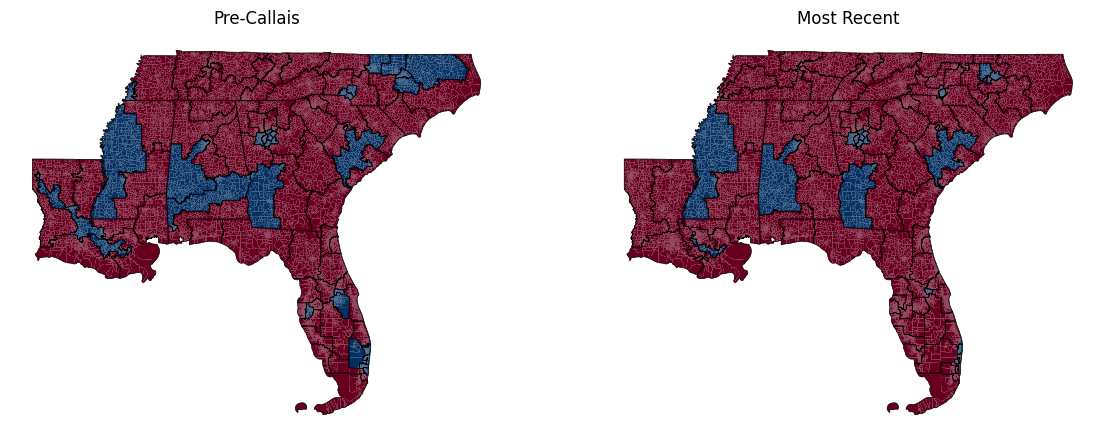

In [61]:
fig, ax = plt.subplots(1, 2, figsize=(14,10))

df_nc.plot(column='nc_dem22',ax=ax[0],vmin=0, vmax=1,cmap='RdBu')
CON_NC22.to_crs(df_nc.crs).plot(ax=ax[0], facecolor='None',edgecolor='k',linewidth=0.5)
df_sc.plot(column='sc_dem',ax=ax[0],vmin=0, vmax=1,cmap='RdBu')
CON_SC.to_crs(df_nc.crs).plot(ax=ax[0], facecolor='None',edgecolor='k',linewidth=0.5)
df_ga.plot(column='ga_dem',ax=ax[0],vmin=0, vmax=1,cmap='RdBu')
CON_GA.to_crs(df_nc.crs).plot(ax=ax[0], facecolor='None',edgecolor='k',linewidth=0.5)
df_fl.plot(column='fl_dem22',ax=ax[0],vmin=0, vmax=1,cmap='RdBu')
CON_FL22.to_crs(df_nc.crs).plot(ax=ax[0], facecolor='None',edgecolor='k',linewidth=0.5)
df_al.plot(column='al_dem22',ax=ax[0],vmin=0, vmax=1,cmap='RdBu')
prec_al22.to_crs(df_nc.crs).plot(ax=ax[0], facecolor='None',edgecolor='k',linewidth=0.5)
df_la.plot(column='la_dem22',ax=ax[0],vmin=0, vmax=1,cmap='RdBu')
prec_la22.to_crs(df_nc.crs).plot(ax=ax[0], facecolor='None',edgecolor='k',linewidth=0.5)
df_ms.to_crs(df_nc.crs).plot(column='ms_dem',ax=ax[0],vmin=0, vmax=1,cmap='RdBu')
prec_ms.to_crs(df_nc.crs).plot(ax=ax[0], facecolor='None',edgecolor='k',linewidth=0.5)
df_tn.plot(column='tn_dem22',ax=ax[0],vmin=0, vmax=1,cmap='RdBu')
prec_tn22.to_crs(df_nc.crs).plot(ax=ax[0], facecolor='None',edgecolor='k',linewidth=0.5)
ax[0].set_title("Pre-Callais")
ax[0].set_axis_off()

df_nc.plot(column='nc_dem',ax=ax[1],vmin=0, vmax=1,cmap='RdBu')
CON_NC.to_crs(df_nc.crs).plot(ax=ax[1], facecolor='None',edgecolor='k',linewidth=0.5)
df_sc.plot(column='sc_dem',ax=ax[1],vmin=0, vmax=1,cmap='RdBu')
CON_SC.to_crs(df_nc.crs).plot(ax=ax[1], facecolor='None',edgecolor='k',linewidth=0.5)
df_ga.plot(column='ga_dem',ax=ax[1],vmin=0, vmax=1,cmap='RdBu')
CON_GA.to_crs(df_nc.crs).plot(ax=ax[1], facecolor='None',edgecolor='k',linewidth=0.5)
df_fl.plot(column='fl_dem',ax=ax[1],vmin=0, vmax=1,cmap='RdBu')
CON_FL.to_crs(df_nc.crs).plot(ax=ax[1], facecolor='None',edgecolor='k',linewidth=0.5)
df_al.plot(column='al_dem',ax=ax[1],vmin=0, vmax=1,cmap='RdBu')
prec_al.to_crs(df_nc.crs).plot(ax=ax[1], facecolor='None',edgecolor='k',linewidth=0.5)
df_la.plot(column='la_dem',ax=ax[1],vmin=0, vmax=1,cmap='RdBu')
prec_la.to_crs(df_nc.crs).plot(ax=ax[1], facecolor='None',edgecolor='k',linewidth=0.5)
df_ms.to_crs(df_nc.crs).plot(column='ms_dem',ax=ax[1],vmin=0, vmax=1,cmap='RdBu')
prec_ms.to_crs(df_nc.crs).plot(ax=ax[1], facecolor='None',edgecolor='k',linewidth=0.5)
df_tn.plot(column='tn_dem',ax=ax[1],vmin=0, vmax=1,cmap='RdBu')
prec_tn.to_crs(df_nc.crs).plot(ax=ax[1], facecolor='None',edgecolor='k',linewidth=0.5)
ax[1].set_title("Most Recent")
ax[1].set_axis_off()

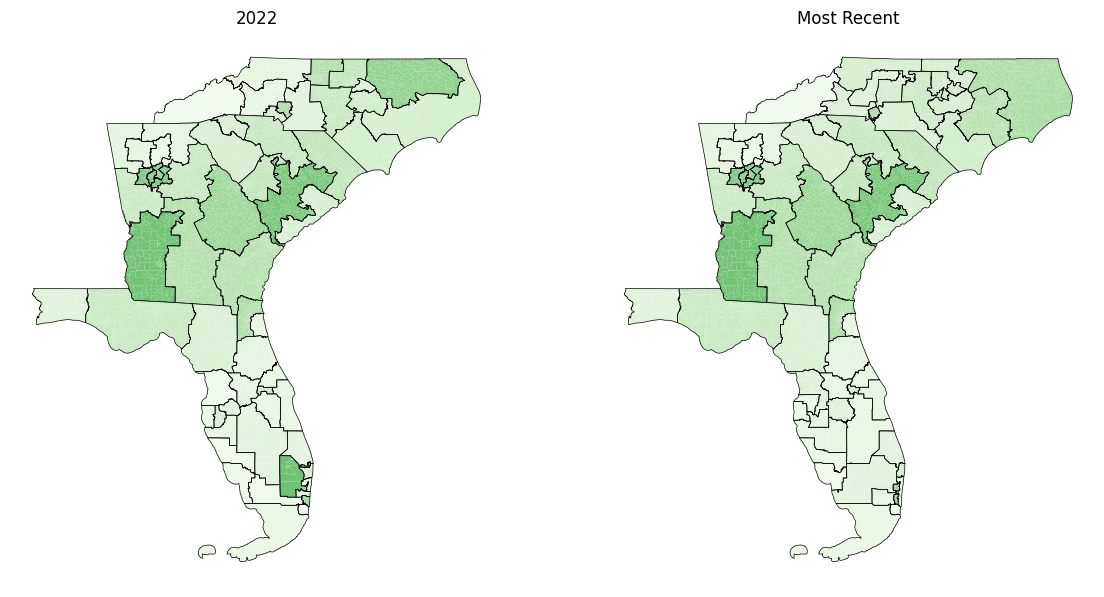

In [29]:
fig, ax = plt.subplots(1, 2, figsize=(14,10))

df_nc["prec_bperc"] = df_nc['CON'].map(df_nc.groupby('CON')['NH_Black'].sum()/df_nc.groupby('CON')['population'].sum())
df_nc["prec_bperc22"] = df_nc['CON22'].map(df_nc.groupby('CON22')['NH_Black'].sum()/df_nc.groupby('CON22')['population'].sum())
df_sc["prec_bperc"] = df_sc['CON'].map(df_sc.groupby('CON')['NH_Black'].sum()/df_sc.groupby('CON')['population'].sum()) 
df_ga["prec_bperc"] = df_ga['CON'].map(df_ga.groupby('CON')['NH_Black'].sum()/df_ga.groupby('CON')['population'].sum())
df_fl["prec_bperc"] = df_fl['CON26'].map(df_fl.groupby('CON26')['NH_Black'].sum()/(df_fl.groupby('CON26')['population'].sum()))
df_fl["prec_bperc22"] = df_fl['CON22'].map(df_fl.groupby('CON22')['NH_Black'].sum()/(df_fl.groupby('CON22')['population'].sum()))

df_nc.plot(column='prec_bperc22',ax=ax[0],vmin=0, vmax=1,cmap='Greens')
CON_NC22.to_crs(df_nc.crs).plot(ax=ax[0], facecolor='None',edgecolor='k',linewidth=0.5)
df_sc.plot(column='prec_bperc',ax=ax[0],vmin=0, vmax=1,cmap='Greens')
CON_SC.to_crs(df_nc.crs).plot(ax=ax[0], facecolor='None',edgecolor='k',linewidth=0.5)
df_ga.plot(column='prec_bperc',ax=ax[0],vmin=0, vmax=1,cmap='Greens')
CON_GA.to_crs(df_nc.crs).plot(ax=ax[0], facecolor='None',edgecolor='k',linewidth=0.5)
df_fl.plot(column='prec_bperc22',ax=ax[0],vmin=0, vmax=1,cmap='Greens')
CON_FL22.to_crs(df_nc.crs).plot(ax=ax[0], facecolor='None',edgecolor='k',linewidth=0.5)
ax[0].set_title("2022")
ax[0].set_axis_off()

df_nc.plot(column='prec_bperc',ax=ax[1],vmin=0, vmax=1,cmap='Greens')
CON_NC.to_crs(df_nc.crs).plot(ax=ax[1], facecolor='None',edgecolor='k',linewidth=0.5)
df_sc.plot(column='prec_bperc',ax=ax[1],vmin=0, vmax=1,cmap='Greens')
CON_SC.to_crs(df_nc.crs).plot(ax=ax[1], facecolor='None',edgecolor='k',linewidth=0.5)
df_ga.plot(column='prec_bperc',ax=ax[1],vmin=0, vmax=1,cmap='Greens')
CON_GA.to_crs(df_nc.crs).plot(ax=ax[1], facecolor='None',edgecolor='k',linewidth=0.5)
df_fl.plot(column='prec_bperc',ax=ax[1],vmin=0, vmax=1,cmap='Greens')
CON_FL.to_crs(df_nc.crs).plot(ax=ax[1], facecolor='None',edgecolor='k',linewidth=0.5)
ax[1].set_title("Most Recent")
ax[1].set_axis_off()

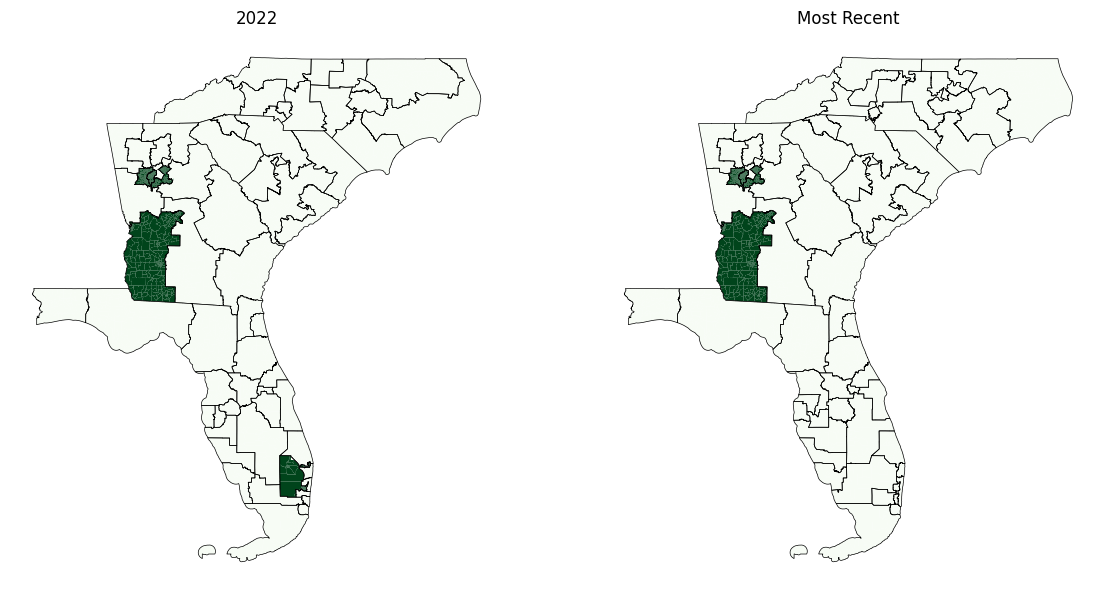

In [30]:
fig, ax = plt.subplots(1, 2, figsize=(14,10))

df_nc["prec_bperc"] = df_nc['CON'].map(df_nc.groupby('CON')['NH_Black'].sum()/df_nc.groupby('CON')['population'].sum()) > 0.5
df_nc["prec_bperc22"] = df_nc['CON22'].map(df_nc.groupby('CON22')['NH_Black'].sum()/df_nc.groupby('CON22')['population'].sum()) > 0.5
df_sc["prec_bperc"] = df_sc['CON'].map(df_sc.groupby('CON')['NH_Black'].sum()/df_sc.groupby('CON')['population'].sum()) > 0.5
df_ga["prec_bperc"] = df_ga['CON'].map(df_ga.groupby('CON')['NH_Black'].sum()/df_ga.groupby('CON')['population'].sum()) > 0.5
df_fl["prec_bperc"] = df_fl['CON26'].map(df_fl.groupby('CON26')['NH_Black'].sum()/(df_fl.groupby('CON26')['population'].sum())) > 0.5
df_fl["prec_bperc22"] = df_fl['CON22'].map(df_fl.groupby('CON22')['NH_Black'].sum()/(df_fl.groupby('CON22')['population'].sum())) > 0.5



df_nc.plot(column='prec_bperc22',ax=ax[0],vmin=0, vmax=1,cmap='Greens')
CON_NC22.to_crs(df_nc.crs).plot(ax=ax[0], facecolor='None',edgecolor='k',linewidth=0.5)
df_sc.plot(column='prec_bperc',ax=ax[0],vmin=0, vmax=1,cmap='Greens')
CON_SC.to_crs(df_nc.crs).plot(ax=ax[0], facecolor='None',edgecolor='k',linewidth=0.5)
df_ga.plot(column='prec_bperc',ax=ax[0],vmin=0, vmax=1,cmap='Greens')
CON_GA.to_crs(df_nc.crs).plot(ax=ax[0], facecolor='None',edgecolor='k',linewidth=0.5)
df_fl.plot(column='prec_bperc22',ax=ax[0],vmin=0, vmax=1,cmap='Greens')
CON_FL22.to_crs(df_nc.crs).plot(ax=ax[0], facecolor='None',edgecolor='k',linewidth=0.5)
ax[0].set_title("2022")
ax[0].set_axis_off()

df_nc.plot(column='prec_bperc',ax=ax[1],vmin=0, vmax=1,cmap='Greens')
CON_NC.to_crs(df_nc.crs).plot(ax=ax[1], facecolor='None',edgecolor='k',linewidth=0.5)
df_sc.plot(column='prec_bperc',ax=ax[1],vmin=0, vmax=1,cmap='Greens')
CON_SC.to_crs(df_nc.crs).plot(ax=ax[1], facecolor='None',edgecolor='k',linewidth=0.5)
df_ga.plot(column='prec_bperc',ax=ax[1],vmin=0, vmax=1,cmap='Greens')
CON_GA.to_crs(df_nc.crs).plot(ax=ax[1], facecolor='None',edgecolor='k',linewidth=0.5)
df_fl.plot(column='prec_bperc',ax=ax[1],vmin=0, vmax=1,cmap='Greens')
CON_FL.to_crs(df_nc.crs).plot(ax=ax[1], facecolor='None',edgecolor='k',linewidth=0.5)
ax[1].set_title("Most Recent")
ax[1].set_axis_off()

In [41]:

df_la["prec_bperc"] = df_la['CON'].map(df_la.groupby('CON')['NH_Black'].sum()/df_la.groupby('CON')['population'].sum()) > 0.5
df_la["prec_bperc22"] = df_la['CON24'].map(df_la.groupby('CON24')['NH_Black'].sum()/df_la.groupby('CON24')['population'].sum()) > 0.5

In [42]:
df_la["prec_bperc_perc"] = df_la['CON'].map(df_la.groupby('CON')['NH_Black'].sum()/df_la.groupby('CON')['population'].sum())
df_la["prec_bperc_perc22"] = df_la['CON24'].map(df_la.groupby('CON24')['NH_Black'].sum()/df_la.groupby('CON24')['population'].sum())

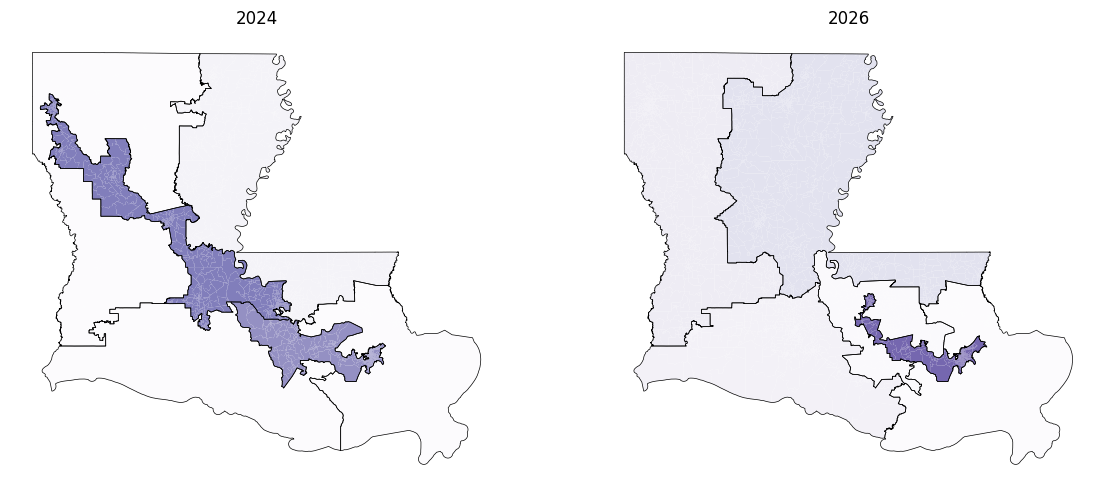

In [44]:
fig, ax = plt.subplots(1, 2, figsize=(14,10))
fig.patch.set_facecolor('none')

df_la.plot(column='prec_bperc_perc22',ax=ax[0],vmin=0.25, vmax=0.75,cmap='Purples')
prec_la22.to_crs(df_nc.crs).plot(ax=ax[0], facecolor='None',edgecolor='k',linewidth=0.5)
ax[0].set_title("2024")
ax[0].set_axis_off()

df_la.plot(column='prec_bperc_perc',ax=ax[1],vmin=0.25, vmax=0.75,cmap='Purples')
prec_la.to_crs(df_nc.crs).plot(ax=ax[1], facecolor='None',edgecolor='k',linewidth=0.5)
ax[1].set_title("2026")
ax[1].set_axis_off()

In [47]:
df_la.keys()

Index(['PRECINCTID', 'population', 'G24PRERTRU', 'G24PREDHAR', 'GCON01RSCA',
       'GCON01DMAN', 'GCON02DCAR', 'GCON02RGRA', 'GCON03RHIG', 'GCON03DGON',
       'GCON04RJOH', 'GCON05RLET', 'GCON05DVAL', 'GCON06DFIE', 'GCON06RGUI',
       'Total', 'Hispanic', 'NH_White', 'NH_Black', 'NH_Other', 'Total_VAP',
       'Hispanic_V', 'NH_White_V', 'NH_Black_V', 'NH_Other_V', 'COUNTYFP',
       'CON', 'SLDU', 'SLDL', 'C_X', 'C_Y', 'CON24', 'CON22', 'geometry',
       'prec_perc', 'prec_perc22', 'la_dem22', 'la_dem', 'b_perc',
       'prec_bperc', 'prec_bperc22', 'prec_bperc_perc', 'prec_bperc_perc22'],
      dtype='object')

In [48]:
df_la["prec_hperc_perc"] = df_la['CON'].map(df_la.groupby('CON')['Hispanic'].sum()/df_la.groupby('CON')['population'].sum())
df_la["prec_hperc_perc22"] = df_la['CON24'].map(df_la.groupby('CON24')['Hispanic'].sum()/df_la.groupby('CON24')['population'].sum())
df_la["prec_wperc_perc"] = df_la['CON'].map(df_la.groupby('CON')['NH_White'].sum()/df_la.groupby('CON')['population'].sum())
df_la["prec_hperc_perc22"] = df_la['CON24'].map(df_la.groupby('CON24')['NH_White'].sum()/df_la.groupby('CON24')['population'].sum())
df_la["prec_operc_perc"] = df_la['CON'].map(df_la.groupby('CON')['NH_Other'].sum()/df_la.groupby('CON')['population'].sum())
df_la["prec_operc_perc22"] = df_la['CON24'].map(df_la.groupby('CON24')['NH_Other'].sum()/df_la.groupby('CON24')['population'].sum())

In [50]:
prec_la22["prec_bperc_perc"] = prec_la22["NH_Black"] / prec_la22["Total"]
prec_la["prec_bperc_perc"] = prec_la["NH_Black"] / prec_la["Total"]

In [58]:
for i in df_la["CON"]:
    print(df_la["prec_perc22"])

0       0.277083
1       0.277083
2       0.277083
3       0.277083
4       0.277083
          ...   
3651    0.275277
3652    0.275277
3653    0.275277
3654    0.275277
3655    0.275277
Name: prec_perc22, Length: 3656, dtype: float64
0       0.277083
1       0.277083
2       0.277083
3       0.277083
4       0.277083
          ...   
3651    0.275277
3652    0.275277
3653    0.275277
3654    0.275277
3655    0.275277
Name: prec_perc22, Length: 3656, dtype: float64
0       0.277083
1       0.277083
2       0.277083
3       0.277083
4       0.277083
          ...   
3651    0.275277
3652    0.275277
3653    0.275277
3654    0.275277
3655    0.275277
Name: prec_perc22, Length: 3656, dtype: float64
0       0.277083
1       0.277083
2       0.277083
3       0.277083
4       0.277083
          ...   
3651    0.275277
3652    0.275277
3653    0.275277
3654    0.275277
3655    0.275277
Name: prec_perc22, Length: 3656, dtype: float64
0       0.277083
1       0.277083
2       0.277083
3       0

In [53]:
from shapely.ops import polylabel

In [59]:
def plot_smart_labels(axis, geo_df, col_name):
    for idx, row in geo_df.iterrows():
        if pd.isna(row.get(col_name)):
            continue
            
        geom = row['geometry']
        if geom is None or geom.is_empty:
            continue
            
        # Get the mathematical visual center
        pt = polylabel(geom, tolerance=0.001)
        label_text = f"{row[col_name] * 100:.1f}%"
        
        # Calculate aspect ratio / shape characteristics
        minx, miny, maxx, maxy = geom.bounds
        width = maxx - minx
        height = maxy - miny
        
        # Identify problematic serpentine districts (like the dark green ones)
        # We also look at the label value to target specific districts if needed
        black_maj = row[col_name] > 0.5
        if black_maj:
            # Shift the text slightly to the right/up from the center point 
            # and point back to the true center with an arrow
            """axis.annotate(
                text=label_text,
                xy=(pt.x, pt.y),          # The arrow points here (inside the district)
                #xytext=(pt.x, pt.y), # Where the text sits
                color='black',
                fontsize=10,
                weight='bold',
                
            )"""
        else:
            # Normal compact districts get cleanly centered text
            axis.text(
                x=pt.x, y=pt.y, s=label_text,
                color='black', fontsize=10, ha='center', va='center'
            )

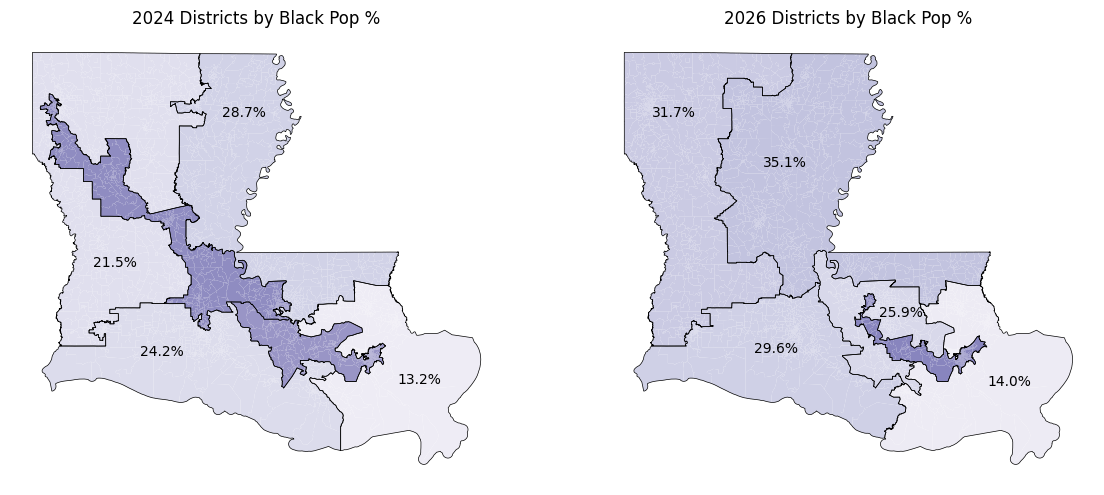

In [61]:
fig, ax = plt.subplots(1, 2, figsize=(14,10))
fig.patch.set_facecolor('none')

df_la.plot(column='prec_bperc_perc22',ax=ax[0],vmin=0, vmax=1,cmap='Purples')
prec_la22.to_crs(df_nc.crs).plot(ax=ax[0], facecolor='None',edgecolor='k',linewidth=0.5)

plot_smart_labels(ax[0], prec_la22.to_crs(df_nc.crs), 'prec_bperc_perc')
ax[0].set_title("2024 Districts by Black Pop %")
ax[0].set_axis_off()

df_la.plot(column='prec_bperc_perc',ax=ax[1],vmin=0, vmax=1,cmap='Purples')
prec_la.to_crs(df_nc.crs).plot(ax=ax[1], facecolor='None',edgecolor='k',linewidth=0.5)
plot_smart_labels(ax[1], prec_la.to_crs(df_nc.crs), 'prec_bperc_perc')
ax[1].set_title("2026 Districts by Black Pop %")
ax[1].set_axis_off()

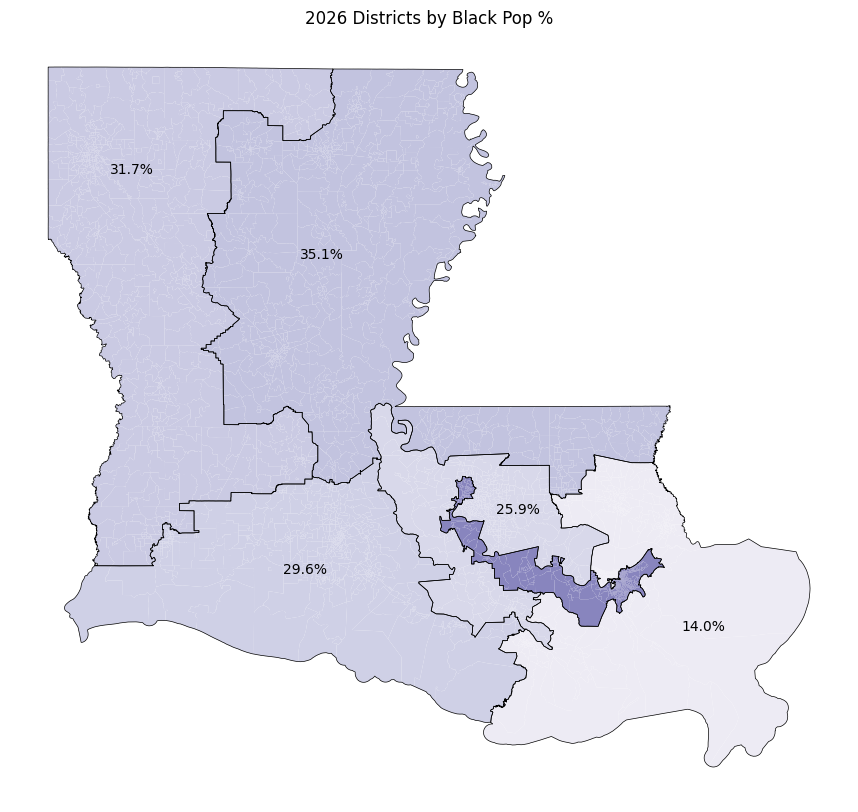

In [62]:
fig, ax = plt.subplots(figsize=(14,10))
fig.patch.set_facecolor('none')

df_la.plot(column='prec_bperc_perc',ax=ax,vmin=0, vmax=1,cmap='Purples')
prec_la.to_crs(df_nc.crs).plot(ax=ax, facecolor='None',edgecolor='k',linewidth=0.5)
plot_smart_labels(ax, prec_la.to_crs(df_nc.crs), 'prec_bperc_perc')
ax.set_title("2026 Districts by Black Pop %")
ax.set_axis_off()

In [65]:
import json

In [106]:
with open('la_seed_plan1.json', 'r') as file:
    la_seed = json.load(file)

In [ ]:
print(la_seed['3400'])

5


In [113]:
for i in range(len(la_seed.keys())):
    df_la['seed'][i] = la_seed[f'{i}']

In [115]:
set(df_la['seed'])

{0, 1, 2, 3, 4, 5}

In [116]:
prec_la_seed = df_la.dissolve(by='seed', aggfunc='sum')

In [118]:
prec_la_seed["prec_bperc_perc"] = prec_la_seed["NH_Black"] / prec_la_seed["Total"]
prec_la_seed["prec_bperc_perc"] = prec_la_seed["NH_Black"] / prec_la_seed["Total"]

In [121]:
df_la["prec_bperc_perc_seed"] = df_la['seed'].map(df_la.groupby('seed')['NH_Black'].sum()/df_la.groupby('seed')['population'].sum())

C:\Users\angel\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\geopandas\geodataframe.py:1528: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  super().__setitem__(key, value)


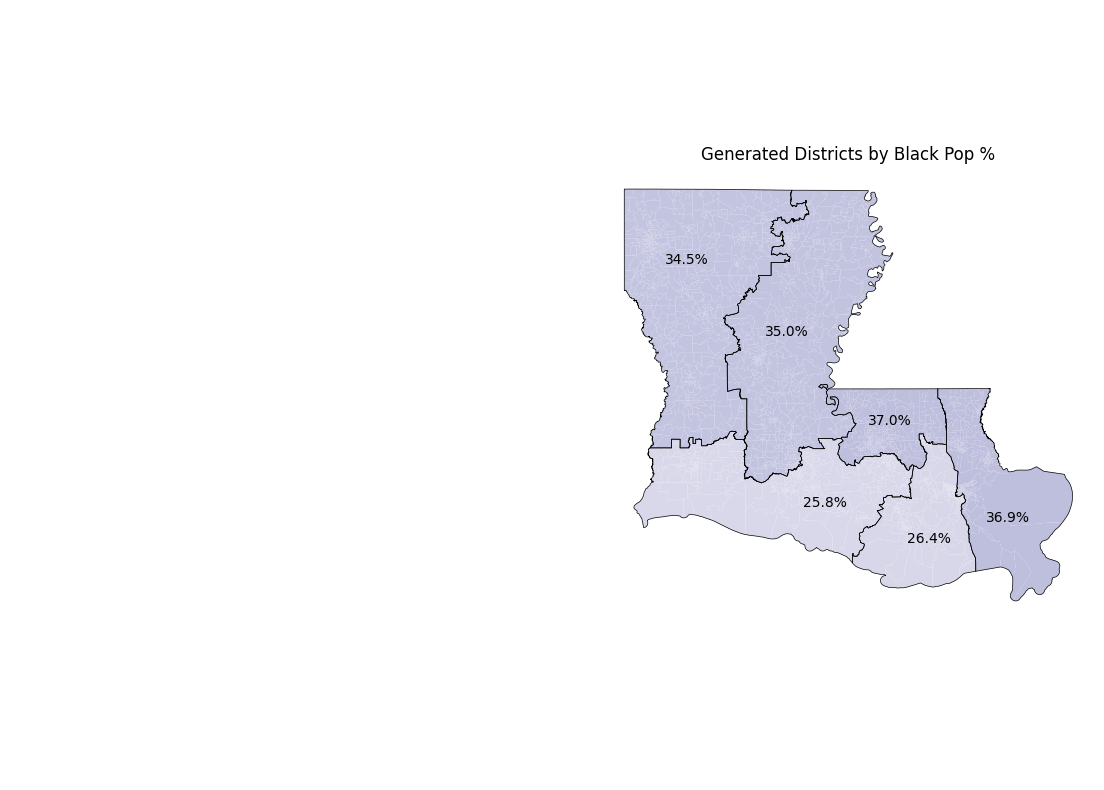

In [126]:
fig, ax = plt.subplots(1,2, figsize=(14,10))
fig.patch.set_facecolor('none')

df_la.plot(column='prec_bperc_perc_seed',ax=ax[1],vmin=0, vmax=1,cmap='Purples')
prec_la_seed.to_crs(df_nc.crs).plot(ax=ax[1], facecolor='None',edgecolor='k',linewidth=0.5)
plot_smart_labels(ax[1], prec_la_seed.to_crs(df_nc.crs), 'prec_bperc_perc')
ax[1].set_title("Generated Districts by Black Pop %")
ax[1].set_axis_off()
ax[0].set_axis_off()

Index(['PRECINCTID', 'population', 'G24PRERTRU', 'G24PREDHAR', 'GCON01RSCA',
       'GCON01DMAN', 'GCON02DCAR', 'GCON02RGRA', 'GCON03RHIG', 'GCON03DGON',
       'GCON04RJOH', 'GCON05RLET', 'GCON05DVAL', 'GCON06DFIE', 'GCON06RGUI',
       'Total', 'Hispanic', 'NH_White', 'NH_Black', 'NH_Other', 'Total_VAP',
       'Hispanic_V', 'NH_White_V', 'NH_Black_V', 'NH_Other_V', 'COUNTYFP',
       'CON', 'SLDU', 'SLDL', 'C_X', 'C_Y', 'CON24', 'CON22', 'geometry',
       'prec_perc', 'prec_perc22', 'la_dem22', 'la_dem', 'prec_bperc_perc',
       'prec_bperc_perc22', 'prec_bperc', 'prec_bperc22', 'seed'],
      dtype='object')

In [ ]:
fig, ax = plt.subplots(figsize=(14,10))
df['b_perc'] = df['NH_Black']/df['population']
df.plot(column='b_perc',ax=ax,vmin=0, vmax=1)
CON.to_crs(df.crs).plot(ax=ax, facecolor='None',edgecolor='white',linewidth=0.5)
ax.set_axis_off()

In [35]:
max(df['d_perc'])

2.9466019417475726

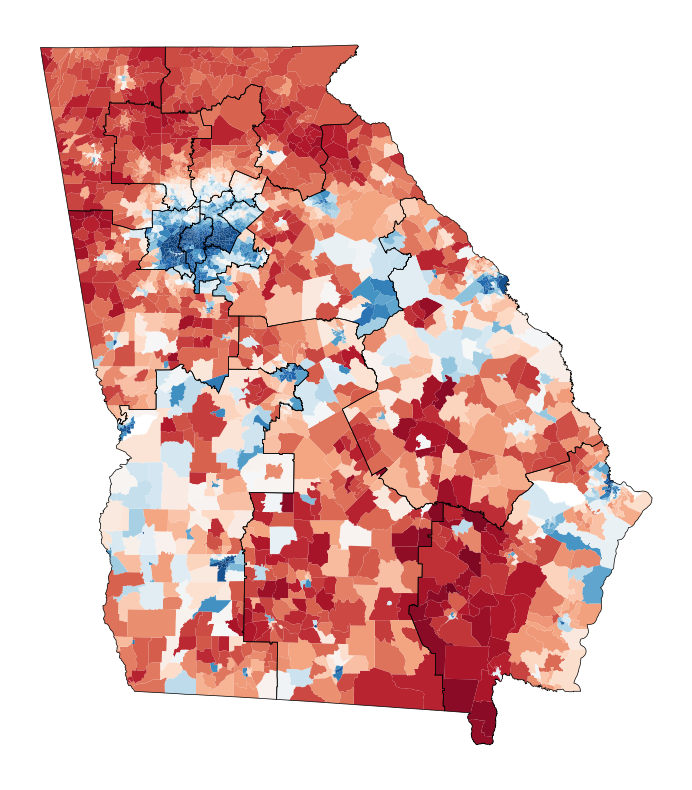

In [43]:
fig, ax = plt.subplots(figsize=(14,10))
df['d_perc'] = df['G20PREDBID']/ (df['G20PREDBID'] + df['G20PRERTRU'])
df.plot(column='d_perc',ax=ax,vmin=0, vmax=1, cmap='RdBu')
CON.to_crs(df.crs).plot(ax=ax, facecolor='None',edgecolor='black',linewidth=0.5)
ax.set_axis_off()

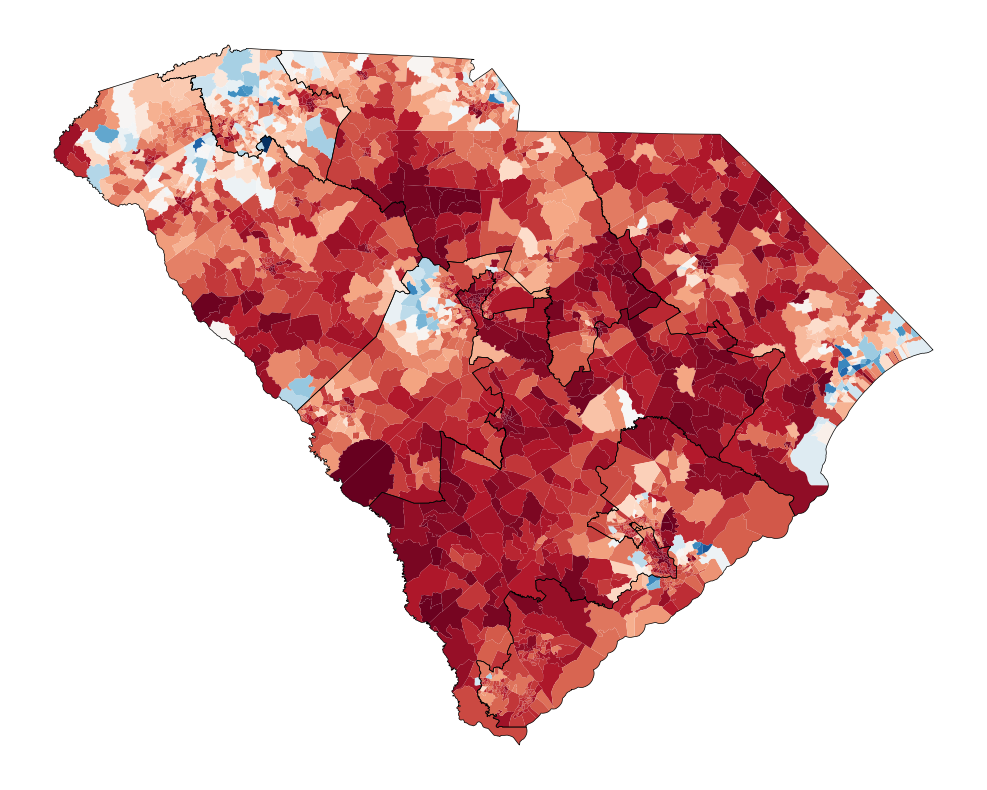

In [ ]:
fig, ax = plt.subplots(figsize=(14,10))
df.plot(column='G24PRERTRU', ax=ax,cmap='RdBu')
CON.to_crs(df.crs).plot(ax=ax, facecolor='None',edgecolor='black',linewidth=0.5)
ax.set_axis_off()

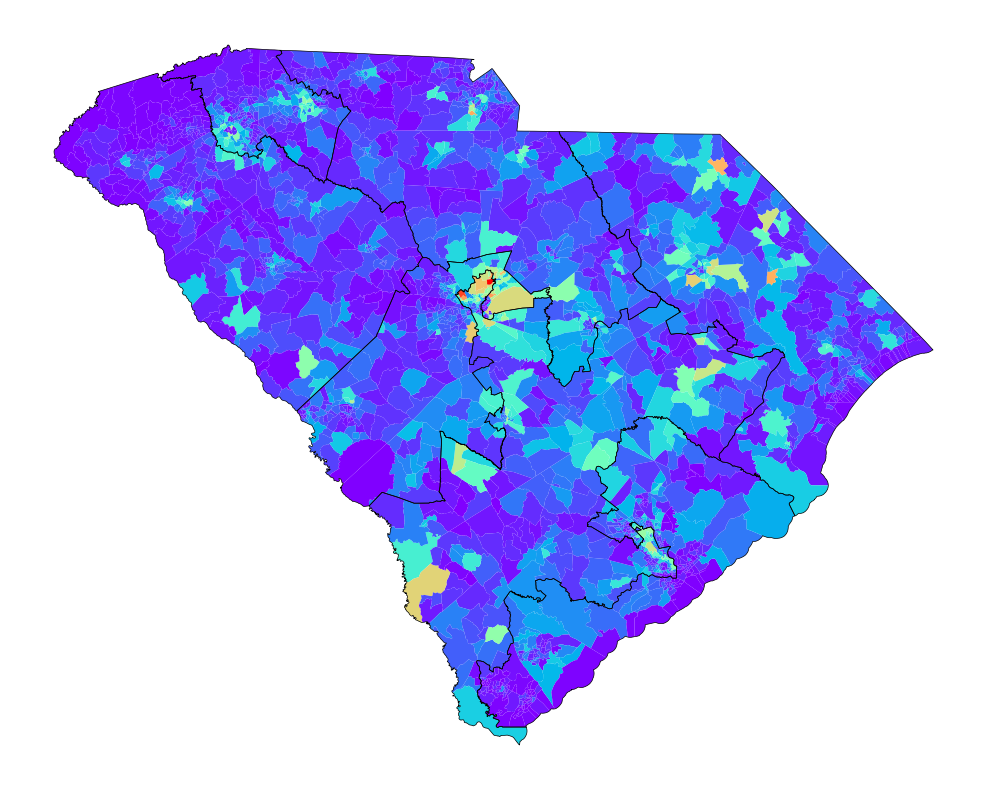

In [6]:
fig, ax = plt.subplots(figsize=(14,10))
df.plot(column='NH_Black', ax=ax,cmap='rainbow')
CON.to_crs(df.crs).plot(ax=ax, facecolor='None',edgecolor='black',linewidth=0.5)
ax.set_axis_off()